In [1]:
import random
import numpy as np
import pandas as pd

G=214

random.seed(G)
np.random.seed(G)

K=(G%3)+5

print("Group Number:",G)
print("Total Medicines:",K)

hidden_probabilities=[]

for i in range(K):

    Pi=0.4+((G+i)%6)*0.07

    hidden_probabilities.append(round(Pi,2))

print("\nHidden Success Probabilities")

for i,p in enumerate(hidden_probabilities):

    print(f"Medicine {i}:{p}")

num_patients=1000

patient_ids=np.arange(num_patients)

severity_scores=[]

for pid in patient_ids:

    severity=(pid%5)+1

    severity_scores.append(severity)

dataset=pd.DataFrame({

    'patient_id':patient_ids,

    'severity_score':severity_scores

})

print("\nFirst 10 Rows")

print(dataset.head(10))

Group Number: 214
Total Medicines: 6

Hidden Success Probabilities
Medicine 0:0.68
Medicine 1:0.75
Medicine 2:0.4
Medicine 3:0.47
Medicine 4:0.54
Medicine 5:0.61

First 10 Rows
   patient_id  severity_score
0           0               1
1           1               2
2           2               3
3           3               4
4           4               5
5           5               1
6           6               2
7           7               3
8           8               4
9           9               5


In [2]:
# ============================================================
# PART-1 : SECTION-2
# Immediate Exploitation Strategy
# Group 214
# ============================================================

# Create separate dataset copy
dataset_IE = dataset.copy()

# Create required dynamic columns
dataset_IE['assigned_medicine'] = None
dataset_IE['clinical_outcome'] = None
dataset_IE['utility_score'] = None

# Track statistics
medicine_rewards = np.zeros(K)
medicine_counts = np.zeros(K)

# Track cumulative reward
cumulative_rewards_IE = []

# Patient counter
current_patient = 0

# ============================================================
# PHASE-1 : INITIAL TESTING
# Test EACH medicine exactly 10 times
# ============================================================

for med in range(K):

    for trial in range(10):

        # Assign medicine
        dataset_IE.loc[current_patient,
                       'assigned_medicine'] = med

        # Hidden success probability
        success_probability = hidden_probabilities[med]

        # Generate clinical outcome
        clinical_outcome = np.random.binomial(
                                1,
                                success_probability
                           )

        dataset_IE.loc[current_patient,
                       'clinical_outcome'] = clinical_outcome

        # Get severity score
        severity = dataset_IE.loc[
                        current_patient,
                        'severity_score'
                   ]

        # Compute utility reward
        utility_score = clinical_outcome * (
                            1 - severity/10
                        )

        dataset_IE.loc[current_patient,
                       'utility_score'] = utility_score

        # Update bandit statistics
        medicine_rewards[med] += utility_score
        medicine_counts[med] += 1

        # Update cumulative reward
        if len(cumulative_rewards_IE)==0:

            cumulative_rewards_IE.append(
                    utility_score
            )

        else:

            cumulative_rewards_IE.append(

                cumulative_rewards_IE[-1]
                +
                utility_score
            )

        # Move to next patient
        current_patient += 1


# ============================================================
# COMPUTE AVERAGE REWARDS
# ============================================================

average_rewards = medicine_rewards / medicine_counts

print("\nAverage Rewards After Initial Testing\n")

for i,a in enumerate(average_rewards):

    print(
        f"Medicine {i}: {a:.4f}"
    )

# Select best medicine
best_medicine = np.argmax(
                    average_rewards
                )

print("\nBest Medicine Selected:",
      best_medicine)

# ============================================================
# PHASE-2 : EXPLOITATION
# Use ONLY best medicine for remaining patients
# ============================================================

while current_patient < 1000:

    dataset_IE.loc[
        current_patient,
        'assigned_medicine'
    ] = best_medicine

    success_probability = hidden_probabilities[
                            best_medicine
                          ]

    clinical_outcome = np.random.binomial(
                            1,
                            success_probability
                        )

    dataset_IE.loc[
        current_patient,
        'clinical_outcome'
    ] = clinical_outcome

    severity = dataset_IE.loc[
                    current_patient,
                    'severity_score'
               ]

    utility_score = clinical_outcome * (
                        1 - severity/10
                    )

    dataset_IE.loc[
        current_patient,
        'utility_score'
    ] = utility_score

    # Update statistics
    medicine_rewards[
        best_medicine
    ] += utility_score

    medicine_counts[
        best_medicine
    ] += 1

    # Update cumulative reward
    cumulative_rewards_IE.append(

        cumulative_rewards_IE[-1]
        +
        utility_score
    )

    current_patient += 1


# ============================================================
# FINAL RESULTS
# ============================================================

final_reward_IE = cumulative_rewards_IE[-1]

print("\n===================================")
print("IMMEDIATE EXPLOITATION RESULTS")
print("===================================")

print("Final Cumulative Reward:",
      round(final_reward_IE,2))

print("Total Patients Processed:",
      current_patient)

print("Selected Best Medicine:",
      best_medicine)

print("\nFinal Medicine Statistics\n")

for i in range(K):

    avg = medicine_rewards[i] / \
          medicine_counts[i]

    print(

        f"Medicine {i} | "
        f"Trials={int(medicine_counts[i])} | "
        f"Average Reward={avg:.4f}"

    )

print("\nFirst 10 Dataset Rows\n")

print(
    dataset_IE.head(10)
)


Average Rewards After Initial Testing

Medicine 0: 0.5800
Medicine 1: 0.6100
Medicine 2: 0.2200
Medicine 3: 0.1500
Medicine 4: 0.4900
Medicine 5: 0.5000

Best Medicine Selected: 1

IMMEDIATE EXPLOITATION RESULTS
Final Cumulative Reward: 533.1
Total Patients Processed: 1000
Selected Best Medicine: 1

Final Medicine Statistics

Medicine 0 | Trials=10 | Average Reward=0.5800
Medicine 1 | Trials=950 | Average Reward=0.5407
Medicine 2 | Trials=10 | Average Reward=0.2200
Medicine 3 | Trials=10 | Average Reward=0.1500
Medicine 4 | Trials=10 | Average Reward=0.4900
Medicine 5 | Trials=10 | Average Reward=0.5000

First 10 Dataset Rows

   patient_id  severity_score assigned_medicine clinical_outcome utility_score
0           0               1                 0                1           0.9
1           1               2                 0                1           0.8
2           2               3                 0                0           0.0
3           3               4                 0 

In [3]:
# ============================================================
# PART-1 : SECTION-3
# Controlled Clinical Trial Strategy
# Epsilon Greedy
# Group 214
# ============================================================

def epsilon_greedy_strategy(epsilon):

    dataset_EG = dataset.copy()

    dataset_EG['assigned_medicine']=None
    dataset_EG['clinical_outcome']=None
    dataset_EG['utility_score']=None

    medicine_rewards=np.zeros(K)
    medicine_counts=np.zeros(K)

    cumulative_rewards=[]

    for patient in range(1000):

        # ===================================================
        # MEDICINE SELECTION
        # ===================================================

        random_number=np.random.random()

        # EXPLORE
        if random_number < epsilon:

            selected_medicine=np.random.randint(
                                    0,
                                    K
                                )

        # EXPLOIT
        else:

            unexplored=np.where(
                            medicine_counts==0
                        )[0]

            if len(unexplored)>0:

                selected_medicine=np.random.choice(
                                        unexplored
                                    )

            else:

                average_rewards=(
                    medicine_rewards
                    /
                    medicine_counts
                )

                selected_medicine=np.argmax(
                                        average_rewards
                                     )

        # ===================================================
        # ASSIGN MEDICINE
        # ===================================================

        dataset_EG.loc[
            patient,
            'assigned_medicine'
        ]=selected_medicine

        # Hidden probability
        success_probability=hidden_probabilities[
                                selected_medicine
                            ]

        # Generate outcome
        clinical_outcome=np.random.binomial(
                                1,
                                success_probability
                           )

        dataset_EG.loc[
            patient,
            'clinical_outcome'
        ]=clinical_outcome

        # Get severity
        severity=dataset_EG.loc[
                    patient,
                    'severity_score'
                 ]

        # Utility reward
        utility_score=clinical_outcome*(
                            1-severity/10
                        )

        dataset_EG.loc[
            patient,
            'utility_score'
        ]=utility_score

        # Update statistics
        medicine_rewards[
            selected_medicine
        ]+=utility_score

        medicine_counts[
            selected_medicine
        ]+=1

        # Update cumulative reward
        if len(cumulative_rewards)==0:

            cumulative_rewards.append(
                utility_score
            )

        else:

            cumulative_rewards.append(

                cumulative_rewards[-1]
                +
                utility_score
            )

    # =======================================================
    # FINAL RESULTS
    # =======================================================

    final_reward=cumulative_rewards[-1]

    print("\n===================================")
    print(f"EPSILON = {epsilon}")
    print("===================================")

    print(
        "Final Cumulative Reward:",
        round(final_reward,2)
    )

    print("\nMedicine Statistics\n")

    for i in range(K):

        if medicine_counts[i]>0:

            avg=medicine_rewards[i]/medicine_counts[i]

        else:

            avg=0

        print(

            f"Medicine {i} | "
            f"Trials={int(medicine_counts[i])} | "
            f"Average Reward={avg:.4f}"

        )

    return dataset_EG,cumulative_rewards

In [4]:
# epsilon=0.01
dataset_001,rewards_001=\
epsilon_greedy_strategy(
    epsilon=0.01
)

# epsilon=0.10
dataset_010,rewards_010=\
epsilon_greedy_strategy(
    epsilon=0.10
)

# epsilon=0.50
dataset_050,rewards_050=\
epsilon_greedy_strategy(
    epsilon=0.50
)


EPSILON = 0.01
Final Cumulative Reward: 492.1

Medicine Statistics

Medicine 0 | Trials=950 | Average Reward=0.4958
Medicine 1 | Trials=7 | Average Reward=0.4714
Medicine 2 | Trials=1 | Average Reward=0.0000
Medicine 3 | Trials=4 | Average Reward=0.2750
Medicine 4 | Trials=2 | Average Reward=0.4000
Medicine 5 | Trials=36 | Average Reward=0.4417

EPSILON = 0.1
Final Cumulative Reward: 500.9

Medicine Statistics

Medicine 0 | Trials=394 | Average Reward=0.4853
Medicine 1 | Trials=527 | Average Reward=0.5309
Medicine 2 | Trials=19 | Average Reward=0.2737
Medicine 3 | Trials=13 | Average Reward=0.3462
Medicine 4 | Trials=19 | Average Reward=0.4053
Medicine 5 | Trials=28 | Average Reward=0.4464

EPSILON = 0.5
Final Cumulative Reward: 468.5

Medicine Statistics

Medicine 0 | Trials=85 | Average Reward=0.4459
Medicine 1 | Trials=567 | Average Reward=0.5254
Medicine 2 | Trials=80 | Average Reward=0.3525
Medicine 3 | Trials=79 | Average Reward=0.2886
Medicine 4 | Trials=90 | Average Reward=0.4

In [5]:
# ============================================================
# PART-1 : SECTION-4
# UCB1 Strategy
# Group 214
# ============================================================

dataset_UCB = dataset.copy()

dataset_UCB['assigned_medicine']=None
dataset_UCB['clinical_outcome']=None
dataset_UCB['utility_score']=None

medicine_rewards=np.zeros(K)

medicine_counts=np.zeros(K)

cumulative_rewards_UCB=[]


# ============================================================
# MAIN LOOP
# ============================================================

for patient in range(1000):

    # ===============================================
    # MEDICINE SELECTION
    # ===============================================

    unexplored=np.where(
                    medicine_counts==0
                )[0]

    # Force initial exploration
    if len(unexplored)>0:

        selected_medicine=np.random.choice(
                                unexplored
                            )

    else:

        average_rewards=(
            medicine_rewards
            /
            medicine_counts
        )

        ucb_values=[]

        for med in range(K):

            exploration_bonus=np.sqrt(

                (2*np.log(patient+1))
                /
                medicine_counts[med]

            )

            ucb=(
                average_rewards[med]
                +
                exploration_bonus
            )

            ucb_values.append(ucb)

        selected_medicine=np.argmax(
                                ucb_values
                             )

    # ===============================================
    # ASSIGN MEDICINE
    # ===============================================

    dataset_UCB.loc[
        patient,
        'assigned_medicine'
    ]=selected_medicine

    # Hidden probability
    success_probability=hidden_probabilities[
                            selected_medicine
                         ]

    # Generate clinical outcome
    clinical_outcome=np.random.binomial(
                            1,
                            success_probability
                        )

    dataset_UCB.loc[
        patient,
        'clinical_outcome'
    ]=clinical_outcome

    # Patient severity
    severity=dataset_UCB.loc[
                patient,
                'severity_score'
             ]

    # Utility reward
    utility_score=clinical_outcome*(
                        1-severity/10
                    )

    dataset_UCB.loc[
        patient,
        'utility_score'
    ]=utility_score

    # Update statistics
    medicine_rewards[
        selected_medicine
    ]+=utility_score

    medicine_counts[
        selected_medicine
    ]+=1

    # Update cumulative reward
    if len(cumulative_rewards_UCB)==0:

        cumulative_rewards_UCB.append(
            utility_score
        )

    else:

        cumulative_rewards_UCB.append(

            cumulative_rewards_UCB[-1]
            +
            utility_score
        )


# ============================================================
# FINAL RESULTS
# ============================================================

final_reward_UCB=\
cumulative_rewards_UCB[-1]

print("\n===================================")
print("UCB1 RESULTS")
print("===================================")

print(
    "Final Cumulative Reward:",
    round(final_reward_UCB,2)
)

print("\nFinal Medicine Statistics\n")

for i in range(K):

    avg=medicine_rewards[i]\
        /medicine_counts[i]

    print(

        f"Medicine {i} | "
        f"Trials={int(medicine_counts[i])} | "
        f"Average Reward={avg:.4f}"

    )

print("\nFirst 10 Dataset Rows\n")

print(
    dataset_UCB.head(10)
)


UCB1 RESULTS
Final Cumulative Reward: 438.5

Final Medicine Statistics

Medicine 0 | Trials=217 | Average Reward=0.4636
Medicine 1 | Trials=375 | Average Reward=0.5211
Medicine 2 | Trials=65 | Average Reward=0.2477
Medicine 3 | Trials=80 | Average Reward=0.2962
Medicine 4 | Trials=93 | Average Reward=0.3269
Medicine 5 | Trials=170 | Average Reward=0.4253

First 10 Dataset Rows

   patient_id  severity_score assigned_medicine clinical_outcome utility_score
0           0               1                 4                1           0.9
1           1               2                 2                0           0.0
2           2               3                 5                1           0.7
3           3               4                 1                1           0.6
4           4               5                 0                0           0.0
5           5               1                 3                1           0.9
6           6               2                 3                0 

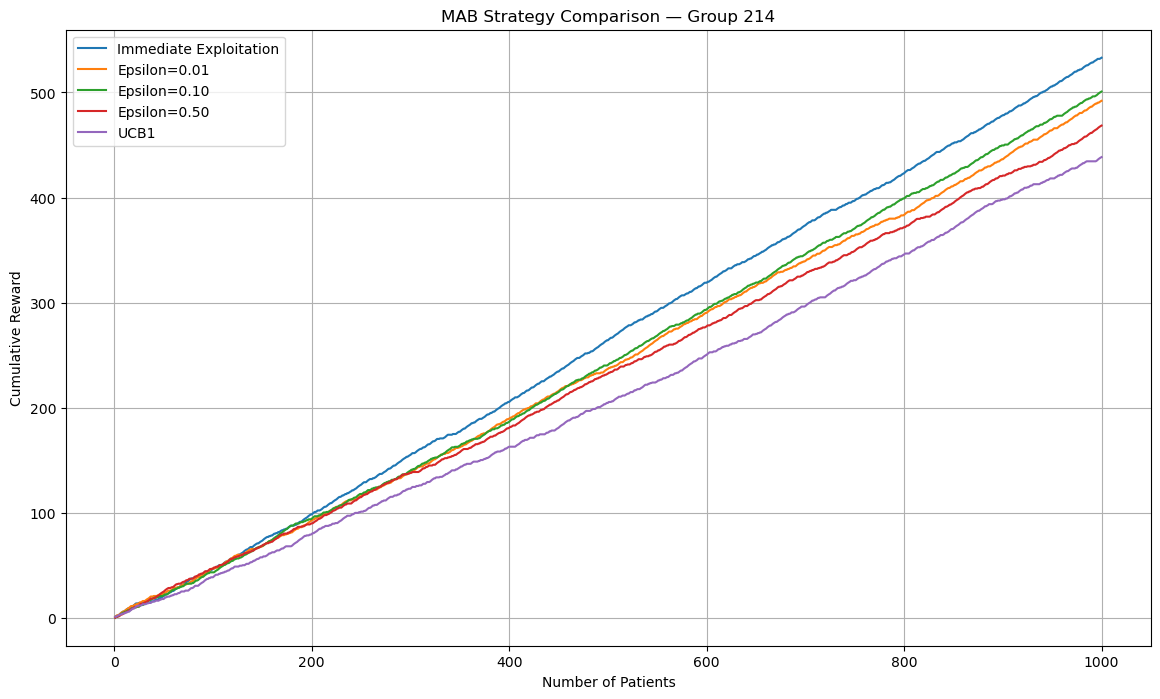

In [6]:
# ============================================================
# PART-1 : SECTION-5
# Comparative Analysis Graph
# Group 214
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

patients=range(1,1001)

# Immediate Exploitation
plt.plot(
    patients,
    cumulative_rewards_IE,
    label='Immediate Exploitation'
)

# Epsilon 0.01
plt.plot(
    patients,
    rewards_001,
    label='Epsilon=0.01'
)

# Epsilon 0.10
plt.plot(
    patients,
    rewards_010,
    label='Epsilon=0.10'
)

# Epsilon 0.50
plt.plot(
    patients,
    rewards_050,
    label='Epsilon=0.50'
)

# UCB1
plt.plot(
    patients,
    cumulative_rewards_UCB,
    label='UCB1'
)

plt.xlabel(
    'Number of Patients'
)

plt.ylabel(
    'Cumulative Reward'
)

plt.title(
    'MAB Strategy Comparison — Group 214'
)

plt.legend()

plt.grid(True)

plt.show()

# PART-1 : SECTION-5  
# Comparative Analysis — Group 214

## Final Reward Comparison

| Strategy | Final Cumulative Reward |
|----------|-------------------------|
| Immediate Exploitation | 533.1 |
| Epsilon = 0.01 | 492.1 |
| Epsilon = 0.10 | 500.9 |
| Epsilon = 0.50 | 468.5 |
| UCB1 | 438.5 |

---

## Question 1: Which strategy achieves the highest cumulative reward at the end of 1000 patients?

### Answer:

The **Immediate Exploitation** strategy achieved the highest cumulative reward.

Actual cumulative rewards obtained:

- Immediate Exploitation = **533.1**
- Epsilon = 0.10 = **500.9**
- Epsilon = 0.01 = **492.1**
- Epsilon = 0.50 = **468.5**
- UCB1 = **438.5**

Immediate Exploitation produced the strongest overall reward because, after the initial testing phase, it quickly identified Medicine-1 as the best medicine and continuously exploited it for the remaining patients.

---

## Question 2: Which strategy identifies the best medicine fastest (earliest convergence)?

### Answer:

**Immediate Exploitation** identified the best medicine fastest.

The algorithm initially tested each medicine exactly 10 times. After this initial exploration phase, it selected **Medicine-1** as the best medicine and immediately converged toward exclusive usage of that medicine.

Because of this rapid commitment, Immediate Exploitation achieved the earliest convergence among all strategies.

---

## Question 3: Which strategy shows the most stable performance over time (least fluctuations)?

### Answer:

Based on the cumulative reward graph, **Immediate Exploitation** demonstrated the most stable performance.

Its cumulative reward curve remained smooth, steadily increasing, and consistently above the other strategies throughout most of the 1000-patient simulation.

The strategy showed very limited fluctuations because it rapidly committed to a single high-performing medicine.

---

## Question 4: Which strategy would you recommend as the safest treatment selection approach for real-world hospital deployment?

### Answer:

For real-world hospital deployment, **Epsilon-Greedy with ε = 0.10** would be recommended as the safest strategy.

Although Immediate Exploitation achieved the highest cumulative reward in this experiment, it completely stops exploration after selecting the current best medicine. In real clinical environments, patient populations and treatment effectiveness can vary over time.

The ε = 0.10 strategy maintains a better balance between **exploration** and **exploitation**, allowing continued testing of alternative medicines while still achieving strong cumulative reward performance.

---

## Comparative Summary (3–5 Sentences)

Immediate Exploitation produced the strongest overall performance with a final cumulative reward of **533.1** and rapidly converged to Medicine-1 after the initial testing phase. The Epsilon-Greedy strategies demonstrated how exploration probability influences learning behaviour, where **ε = 0.10** achieved a balanced trade-off between exploration and exploitation, while **ε = 0.50** suffered from excessive random exploration. UCB1 achieved comparatively lower cumulative reward performance in this experiment. Overall, Immediate Exploitation achieved the highest reward, while **ε = 0.10** represents a safer and more practical strategy for real-world clinical deployment.